In [3]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import sys
sys.path.insert(0, '/home/lifazhi/boiler-draft-helper')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.features.extractor import TargetHistoryExtractor
from src.utils.config import PRESSURE_MAIN, OXYGEN_MAIN

plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


In [4]:
# 1. 加载数据
data_path = Path("../output/all_data_cleaned.feather") 
df = pd.read_feather(data_path)

print(f"数据形状: {df.shape}")
print(f"时间范围: {df.index.min()} ~ {df.index.max()}")
df.head()

数据形状: (585939, 76)
时间范围: 0 ~ 585938


,TIME,D62AX002,MSFLOW,2AH18CP01,2AH18CP002,2BK10CP004,2BK2CP004,2BK10CP005,2BK2CP005,2LA10CP006,...,2BK2CP11,2BK2CP12,2BK10CT226,2BK10CT229,2BK10CT232,2BK2CT226,2BK2CT232,2LA30CT11,2LA40CT11,source_file
0,2024-10-07 17:19:00,15.6988,80.1186,1.9164,1.9200,-27.8456,-26.3198,-28.6085,-30.4333,9.8184,...,6.4266,6.6021,739.5345,750.8080,744.4505,774.9640,796.2714,132.1248,131.7345,锅炉2号机组-60秒2024年10月-online.xlsx
1,2024-10-07 17:20:00,15.7003,79.5984,1.8834,1.8883,9.5362,14.1135,10.2991,10.3814,10.5260,...,5.9063,6.0551,741.7352,753.8527,747.4896,775.3356,798.3257,132.3478,131.9576,锅炉2号机组-60秒2024年10月-online.xlsx
2,2024-10-07 17:21:00,15.5752,80.0997,1.9103,1.9127,-105.6607,-102.6091,-105.2792,-105.5783,10.6805,...,6.1123,6.3450,744.1600,756.3002,750.5781,779.3801,801.8297,132.5293,132.1391,锅炉2号机组-60秒2024年10月-online.xlsx
3,2024-10-07 17:22:00,15.5706,79.6256,1.9359,1.9396,-314.3119,-317.3635,-314.6933,-322.4306,9.8413,...,6.1062,6.3076,743.3531,753.2534,749.7482,777.4272,801.1755,132.7524,132.4178,锅炉2号机组-60秒2024年10月-online.xlsx
4,2024-10-07 17:23:00,15.9521,79.5688,1.9420,1.9445,-246.7959,-244.8886,-246.4144,-248.2393,9.8051,...,6.0078,6.0223,738.0164,744.2209,741.7364,769.3495,793.3322,132.9754,132.6966,锅炉2号机组-60秒2024年10月-online.xlsx


In [5]:
# 2. 截取一部分数据进行验证
df = df.set_index("TIME")
df.index = pd.to_datetime(df.index)
start_idx = df.index.get_loc("2026-01-08 23:57:00")
sample_size = 500
df_sample = df.iloc[start_idx:start_idx + sample_size].copy()

print(f"样本数据形状: {df_sample.shape}")
df_sample[[PRESSURE_MAIN, OXYGEN_MAIN]].head(10)

样本数据形状: (500, 75)


,2BK10CP004,2BK10CQ1
TIME,,
2026-01-08 23:57:00,-124.3515,4.5261
2026-01-08 23:58:00,-175.0839,4.4915
2026-01-10 00:00:00,-158.3003,3.8880
2026-01-10 00:01:00,-83.9182,4.0075
2026-01-10 00:02:00,-120.9185,3.8440
2026-01-10 00:03:00,-88.4956,3.8252
2026-01-10 00:04:00,-127.7846,3.8456
2026-01-10 00:05:00,-105.2792,3.7277
2026-01-10 00:06:00,-97.2688,3.8095


In [6]:
# 3. 提取特征

extractor = TargetHistoryExtractor(
    target_vars=[PRESSURE_MAIN, OXYGEN_MAIN],
    lags=[1, 2, 3, 5, 10],
)
features_df = extractor.extract(df_sample)


print(f"提取的特征数量: {features_df.shape[1]}")
print(f"特征名称:\n{extractor.feature_names}")

提取的特征数量: 26
特征名称:
['2BK10CP004_lag_1', '2BK10CP004_lag_2', '2BK10CP004_lag_3', '2BK10CP004_lag_5', '2BK10CP004_lag_10', '2BK10CP004_trend_slope_5', '2BK10CP004_trend_accel_5', '2BK10CP004_trend_slope_10', '2BK10CP004_trend_accel_10', '2BK10CP004_trend_slope_20', '2BK10CP004_trend_accel_20', '2BK10CP004_trend_slope_30', '2BK10CP004_trend_accel_30', '2BK10CQ1_lag_1', '2BK10CQ1_lag_2', '2BK10CQ1_lag_3', '2BK10CQ1_lag_5', '2BK10CQ1_lag_10', '2BK10CQ1_trend_slope_5', '2BK10CQ1_trend_accel_5', '2BK10CQ1_trend_slope_10', '2BK10CQ1_trend_accel_10', '2BK10CQ1_trend_slope_20', '2BK10CQ1_trend_accel_20', '2BK10CQ1_trend_slope_30', '2BK10CQ1_trend_accel_30']


In [7]:
# 4. 合并原始数据和特征用于对比
combined = pd.concat([df_sample[[PRESSURE_MAIN, OXYGEN_MAIN]], features_df], axis=1)
combined.head(10)

,2BK10CP004,2BK10CQ1,2BK10CP004_lag_1,2BK10CP004_lag_2,2BK10CP004_lag_3,2BK10CP004_lag_5,2BK10CP004_lag_10,2BK10CP004_trend_slope_5,2BK10CP004_trend_accel_5,2BK10CP004_trend_slope_10,...,2BK10CQ1_lag_5,2BK10CQ1_lag_10,2BK10CQ1_trend_slope_5,2BK10CQ1_trend_accel_5,2BK10CQ1_trend_slope_10,2BK10CQ1_trend_accel_10,2BK10CQ1_trend_slope_20,2BK10CQ1_trend_accel_20,2BK10CQ1_trend_slope_30,2BK10CQ1_trend_accel_30
TIME,,,,,,,,,,,,,,,,,,,,,
2026-01-08 23:57:00,-124.3515,4.5261,-124.3515,-124.3515,-124.3515,-124.3515,-124.3515,0.00000,0.000000,0.000000,...,4.5261,4.5261,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2026-01-08 23:58:00,-175.0839,4.4915,-124.3515,-124.3515,-124.3515,-124.3515,-124.3515,-50.73240,0.000000,-50.732400,...,4.5261,4.5261,-0.03460,0.000000,-0.034600,0.000000,-0.034600,0.000000,-0.034600,0.000000
2026-01-10 00:00:00,-158.3003,3.8880,-175.0839,-124.3515,-124.3515,-124.3515,-124.3515,-16.97440,33.758000,-16.974400,...,4.5261,4.5261,-0.31905,-0.284450,-0.319050,-0.284450,-0.319050,-0.284450,-0.319050,-0.284450
2026-01-10 00:01:00,-83.9182,4.0075,-158.3003,-175.0839,-124.3515,-124.3515,-124.3515,13.80835,31.278625,13.808350,...,4.5261,4.5261,-0.21593,0.038525,-0.215930,0.038525,-0.215930,0.038525,-0.215930,0.038525
2026-01-10 00:02:00,-120.9185,3.8440,-83.9182,-158.3003,-175.0839,-124.3515,-124.3515,9.80317,6.075907,9.803170,...,4.5261,4.5261,-0.18482,0.033229,-0.184820,0.033229,-0.184820,0.033229,-0.184820,0.033229
2026-01-10 00:03:00,-88.4956,3.8252,-120.9185,-83.9182,-158.3003,-124.3515,-124.3515,21.05584,-5.721700,11.890223,...,4.5261,4.5261,-0.13766,0.063314,-0.152214,0.032839,-0.152214,0.032839,-0.152214,0.032839
2026-01-10 00:04:00,-127.7846,3.8456,-88.4956,-120.9185,-83.9182,-175.0839,-124.3515,5.64540,-11.279929,7.152111,...,4.4915,4.5261,-0.02671,-0.003821,-0.122075,0.031339,-0.122075,0.031339,-0.122075,0.031339
2026-01-10 00:05:00,-105.2792,3.7277,-127.7846,-88.4956,-120.9185,-158.3003,-124.3515,-4.95881,3.378536,6.457338,...,3.8880,4.5261,-0.05580,0.009314,-0.109169,0.022123,-0.109169,0.022123,-0.109169,0.022123
2026-01-10 00:06:00,-97.2688,3.8095,-105.2792,-127.7846,-88.4956,-83.9182,-124.3515,3.05158,0.926386,6.236648,...,4.0075,4.5261,-0.01665,0.004493,-0.090415,0.020591,-0.090415,0.020591,-0.090415,0.020591


DatetimeIndex(['2026-01-08 23:57:00', '2026-01-08 23:58:00',
               '2026-01-10 00:00:00', '2026-01-10 00:01:00',
               '2026-01-10 00:02:00', '2026-01-10 00:03:00',
               '2026-01-10 00:04:00', '2026-01-10 00:05:00',
               '2026-01-10 00:06:00', '2026-01-10 00:07:00'],
              dtype='datetime64[ns]', name='TIME', freq=None)


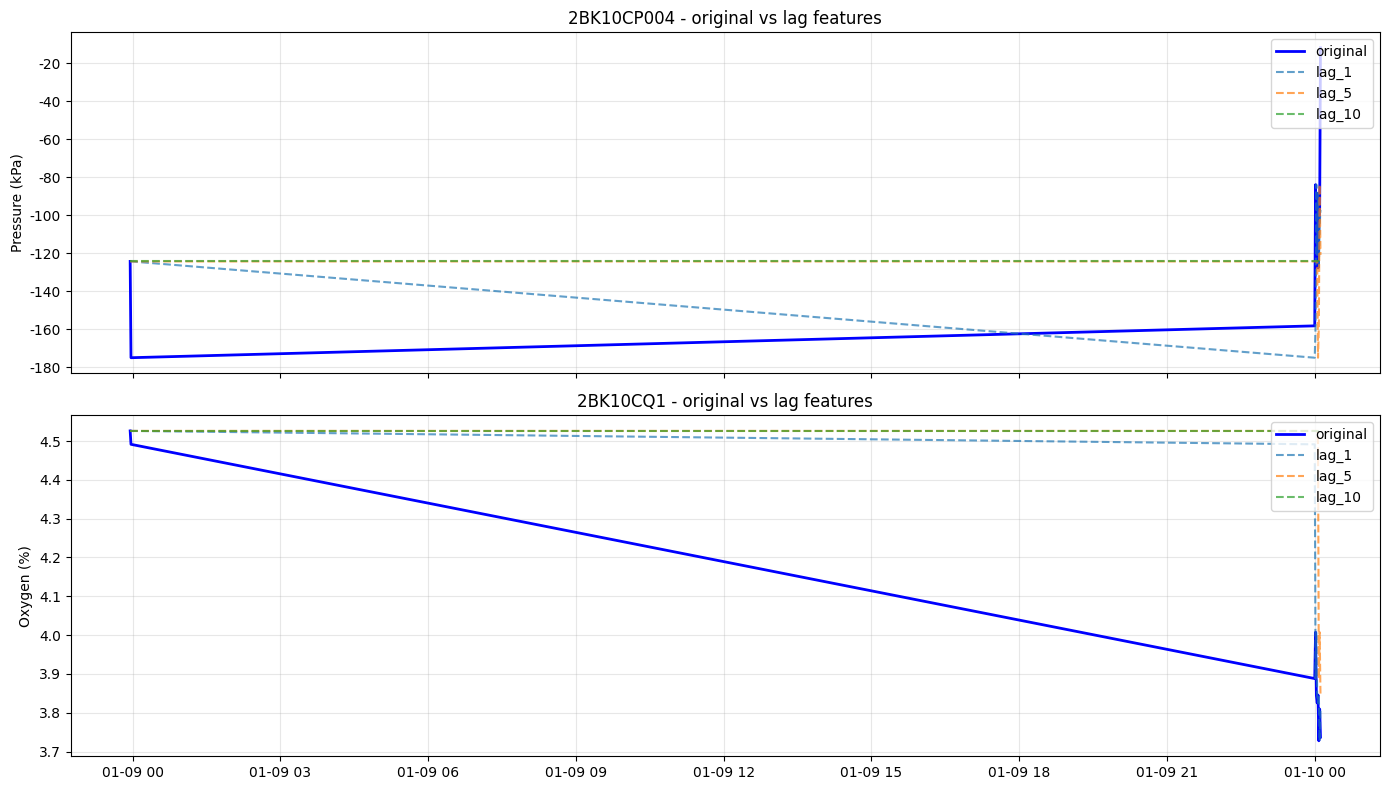

In [12]:
# 5. 可视化验证 - 滞后特征
df_sample = df_sample[:10]
print(df_sample.index)
features_df = features_df[:10]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 炉膛压力及其滞后特征
ax1 = axes[0]
ax1.plot(df_sample.index, df_sample[PRESSURE_MAIN], 'b-', label='original', linewidth=2)
for lag in [1, 5, 10]:
    ax1.plot(df_sample.index, features_df[f"{PRESSURE_MAIN}_lag_{lag}"],
             '--', label=f'lag_{lag}', alpha=0.7)
ax1.set_ylabel('Pressure (kPa)')
ax1.legend(loc='upper right')
ax1.set_title(f'{PRESSURE_MAIN} - original vs lag features')
ax1.grid(True, alpha=0.3)

# 含氧量及其滞后特征
ax2 = axes[1]
ax2.plot(df_sample.index, df_sample[OXYGEN_MAIN], 'b-', label='original', linewidth=2)
for lag in [1, 5, 10]:
    ax2.plot(df_sample.index, features_df[f"{OXYGEN_MAIN}_lag_{lag}"],
             '--', label=f'lag_{lag}', alpha=0.7)
ax2.set_ylabel('Oxygen (%)')
ax2.legend(loc='upper right')
ax2.set_title(f'{OXYGEN_MAIN} - original vs lag features')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# 6. 可视化验证 - 趋势特征
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 原始值
ax1 = axes[0]
ax1.plot(df_sample.index, df_sample[PRESSURE_MAIN], 'b-', linewidth=1.5)
ax1.set_ylabel('原始值')
ax1.set_title(f'{PRESSURE_MAIN} - 原始数据')
ax1.grid(True, alpha=0.3)

# 趋势斜率
ax2 = axes[1]
for window in [5, 10, 20]:
    ax2.plot(df_sample.index, features_df[f"{PRESSURE_MAIN}_trend_slope_{window}"],
             '-', label=f'window={window}', alpha=0.8)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_ylabel('趋势斜率')
ax2.legend(loc='upper right')
ax2.set_title('趋势斜率 (正值=上升, 负值=下降)')
ax2.grid(True, alpha=0.3)

# 趋势加速度
ax3 = axes[2]
for window in [5, 10, 20]:
    ax3.plot(df_sample.index, features_df[f"{PRESSURE_MAIN}_trend_accel_{window}"],
             '-', label=f'window={window}', alpha=0.8)
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax3.set_ylabel('趋势加速度')
ax3.legend(loc='upper right')
ax3.set_title('趋势加速度 (正值=加速上升, 负值=加速下降)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 7. 数值验证 - 检查滞后特征是否正确
print("=== 滞后特征验证 ===")
var = PRESSURE_MAIN
for lag in [1, 2, 5]:
    manual_lag = df_sample[var].shift(lag)
    extracted_lag = features_df[f"{var}_lag_{lag}"]
    match = np.allclose(manual_lag.fillna(df_sample[var].iloc[0]), extracted_lag)
    print(f"lag_{lag}: {'✓ 正确' if match else '✗ 错误'}")

In [ ]:
# 8. 数值验证 - 检查趋势斜率
print("\n=== 趋势斜率验证 ===")
var = PRESSURE_MAIN
window = 5
data = df_sample[var].values[:15]  # 取前15个点
print(f"原始数据 (前15个点):\n{data[:15]}")

# 手动计算第10个点的趋势斜率
test_point = 10
x = np.arange(window)
y = data[test_point-window+1:test_point+1]
slope_manual = np.polyfit(x, y, 1)[0]
slope_extracted = features_df[f"{var}_trend_slope_{window}"].iloc[test_point]
print(f"\n第{test_point}个点, window={window}:")
print(f"窗口数据: {y}")
print(f"手动计算斜率: {slope_manual:.6f}")
print(f"提取特征斜率: {slope_extracted:.6f}")
print(f"差异: {abs(slope_manual - slope_extracted):.10f}")

In [ ]:
# 9. 相关性分析 - 特征与目标变量的关系
print("\n=== 特征相关性分析 ===")
target = PRESSURE_MAIN
target_series = df_sample[target]

# 计算滞后特征与目标的相关性
lag_corr = {}
for lag in [1, 2, 3, 5, 10]:
    lag_corr[f"lag_{lag}"] = features_df[f"{target}_lag_{lag}"].corr(target_series)

# 计算趋势特征与目标变化的相关性
target_change = target_series.diff()
trend_corr = {}
for window in [5, 10, 20]:
    trend_corr[f"slope_{window}"] = features_df[f"{target}_trend_slope_{window}"].corr(target_change)

print("\n滞后特征与目标变量的相关性:")
for k, v in lag_corr.items():
    print(f"  {k}: {v:.4f}")

print("\n趋势斜率与目标变化的相关性:")
for k, v in trend_corr.items():
    print(f"  {k}: {v:.4f}")

In [ ]:
# 10. 选择特定时间段进行详细验证
# 如果数据有时间索引，可以选择一个变化明显的时段
if hasattr(df_sample.index, 'to_pydatetime'):
    print("\n数据有时间索引，可以选择特定时段:")
    print(f"可用时间范围: {df_sample.index.min()} ~ {df_sample.index.max()}")

    # 示例：选择压力变化较大的时段
    pressure_diff = df_sample[PRESSURE_MAIN].diff().abs()
    high_change_mask = pressure_diff > pressure_diff.quantile(0.8)
    high_change_indices = df_sample.index[high_change_mask]
    if len(high_change_indices) > 0:
        print(f"\n压力变化较大的时间点 (前10个):")
        print(high_change_indices[:10])